## AVANCE 2 - DISEÑO DE LA SOLUCIÓN
presentación de los algoritmos seleccionados y demás especificaciones del modelo.

   1) Decision Tree Regressor
      - Justificación: Modelo base simple, permite análisis de complejidad
      - Parámetro clave: max_depth (analizamos convergencia)
   
   2) Random Forest Regressor  
      - Justificación: Múltiples árboles → mejor generalización
      - Paralela: Usa n_jobs=-1 (más rápido)



In [1]:
# Librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
plt.style.use('ggplot')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Definimos la ruta a los datos desde src hacia data
proyecto_root = Path.cwd().parent
ruta_X = proyecto_root / "data" / "X_modelo.csv"
ruta_y = proyecto_root / "data" / "y_modelo.csv"

# Cargar las bases de datos
X = pd.read_csv(ruta_X)
y = pd.read_csv(ruta_y)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (260853, 14)
Dimensiones de y: (260853, 1)


,edad,CANCER,DIABETES,ENF_CARDIACA,HIPERTENSION,ENF_PULMONAR,num_condiciones,meses_expuesto_total,Sexo_Cd_limpio_M,Sexo_Cd_limpio_NOBINARIO,CIUDAD_NORM_CALI,CIUDAD_NORM_CARTAGENA,CIUDAD_NORM_MEDELLIN,CIUDAD_NORM_SIN INFORMACION
0,57,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
1,14,0,0,0,0,0,0,11.991786,True,False,False,False,True,False
2,11,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
3,36,0,0,0,0,0,0,11.991786,False,False,False,True,False,False
4,16,0,0,0,0,0,0,11.991786,True,False,True,False,False,False


In [3]:
# Dividiendo los datos para entrenar Decission Tree Regresion - Random Forest

# Aseguramos  que 'y' sea un array 1D 
y_target = y['total_pagado'] if 'total_pagado' in y.columns else y.values.ravel()

#Dividimos los datos en 80% para entrenamiento y 20% para validación
X_train, X_val, y_train, y_val = train_test_split(X, y_target, test_size=0.2, random_state=42)


In [4]:
# Modelo base para comparar contra el optimizado
rf_inicial = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_inicial.fit(X_train, y_train)

print("Random Forest base entrenado para comparar contra el optimizado")
print(f"Score en validación del modelo base: {rf_inicial.score(X_val, y_val):.6f}")

Random Forest base entrenado para comparar contra el optimizado
Score en validación del modelo base: 0.125813


In [6]:
# Modelo base Decision Tree para comparar contra el optimizado
dt_inicial = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_inicial.fit(X_train, y_train)

print("Decision Tree base entrenado para comparar contra el optimizado")
print(f"Score en validación del modelo base (max_depth=10): {dt_inicial.score(X_val, y_val):.6f}")

Decision Tree base entrenado para comparar contra el optimizado
Score en validación del modelo base (max_depth=10): 0.158426


# OPTIMIZACIÓN DE HIPERPARÁMETROS: GridSearchCV para RandomForest

GridSearchCV prueba TODAS las combinaciones de parámetros y encuentra la mejor usando Cross Validation.
Esto garantiza que los parámetros elegidos generalizan bien a datos nuevos.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("=" * 80)
print("EJECUTANDO GridSearchCV para encontrar los MEJORES parámetros de RandomForest")
print("=" * 80)
print()

# Definir la grilla de parámetros a probar
param_grid_rf = {
    'n_estimators': [50, 100, 150],           # Cantidad de árboles
    'max_depth': [10, 20, 30, 50],            # Profundidad máxima
    'min_samples_split': [2, 5, 10],          # Muestras mínimas para dividir nodo
    'min_samples_leaf': [1, 2, 4],            # Muestras mínimas en hoja terminal
}

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,  # 5-Fold Cross Validation
    scoring='neg_mean_squared_error',  # Optimiza por MSE
    n_jobs=-1,  # Paralela todos los núcleos
    verbose=1
)

# Ejecutar búsqueda
print("Buscando la mejor combinación de parámetros")
grid_search.fit(X_train, y_train)

print("\n" + "=" * 80)
print("RESULTADOS DE LA BÚSQUEDA")
print("=" * 80)
print(f"\n✓ Mejores parámetros encontrados:")
for param, valor in grid_search.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n✓ Mejor score medio de CV (neg MSE): {grid_search.best_score_:.6f}")
print(f"✓ Score en validación (R²): {grid_search.best_estimator_.score(X_val, y_val):.6f}")

# Comparar con el modelo inicial
print(f"\n✓ Score del Random Forest INICIAL (sin optimizar): {rf_inicial.score(X_val, y_val):.6f}")

# Guardar el mejor modelo
rf_optimizado = grid_search.best_estimator_
print(f"\n✓ Modelo optimizado guardado en: rf_optimizado")

# Mostrar tabla de todos los resultados
print("\n" + "=" * 80)
print("TOP 10 MEJORES COMBINACIONES DE PARÁMETROS")
print("=" * 80)
resultados_df = pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score')
top_10 = resultados_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
                          'param_min_samples_leaf', 'mean_test_score', 'std_test_score']].head(10)
print(top_10.to_string(index=False))

EJECUTANDO GridSearchCV para encontrar los MEJORES parámetros de RandomForest

Buscando la mejor combinación de parámetros...
(Esto puede tomar 1-2 minutos dependiendo de tu CPU)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Calculando Correlación (Pearson) y Relevancia (Feature Importance)...

COMPARACIÓN: Correlación vs Relevancia (Random Forest base)


,Correlación (Abs),Relevancia (Árbol)
CANCER,0.062704,0.002029
CIUDAD_NORM_CALI,0.017937,0.021533
CIUDAD_NORM_CARTAGENA,0.027244,0.019857
CIUDAD_NORM_MEDELLIN,0.082145,0.022967
CIUDAD_NORM_SIN INFORMACION,0.010811,0.001145
DIABETES,0.047173,0.001427
ENF_CARDIACA,0.078185,0.002161
ENF_PULMONAR,0.056151,0.001001
HIPERTENSION,0.164493,0.002679
Sexo_Cd_limpio_M,0.140538,0.073958


/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_50444/1345110345.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_50444/1345110345.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')


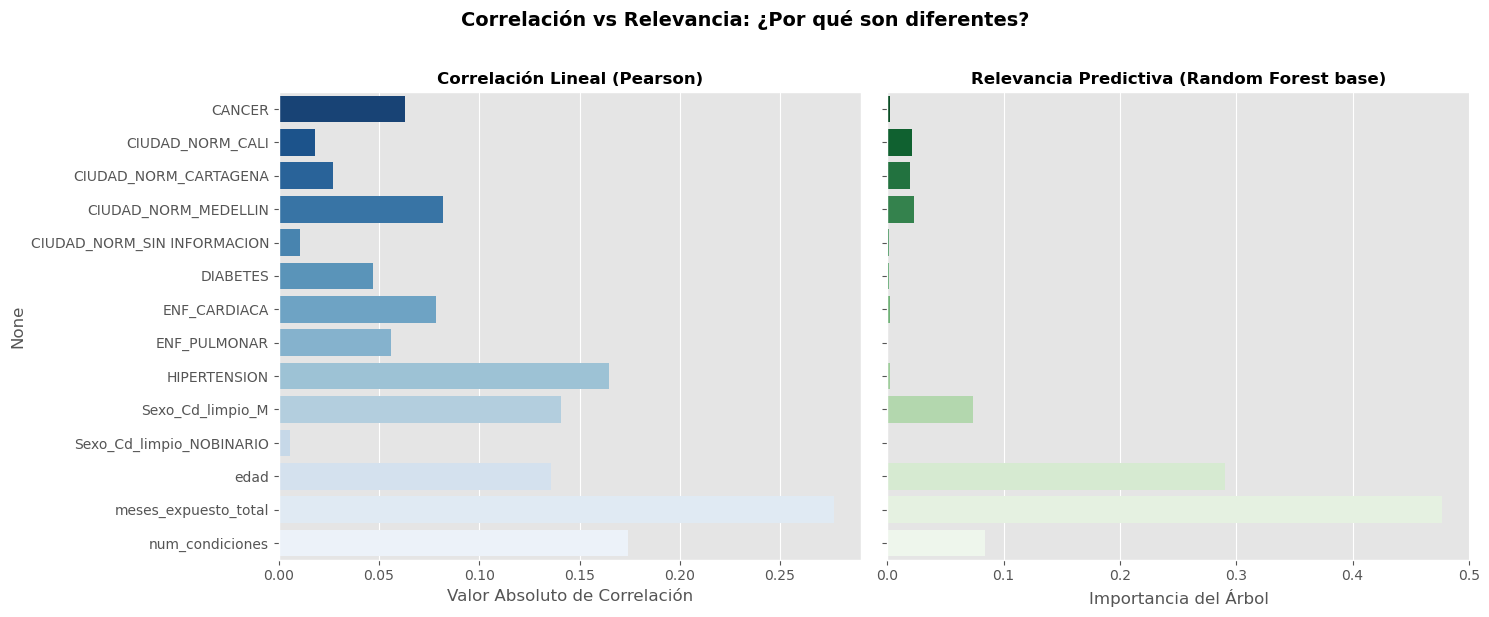

In [ ]:
# Comparación final usando el modelo optimizado

def comparar_correlacion_vs_importancia(X, y_target, modelo, nombre_modelo='Random Forest optimizado'):
    """
    Compara la correlación de Pearson contra la importancia del modelo.
    """
    print("Calculando Correlación (Pearson) y Relevancia (Feature Importance)\n")

    correlacion = X.corrwith(y_target).abs().sort_values(ascending=False)
    relevancia = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

    comparativa = pd.DataFrame({
        'Correlación (Abs)': correlacion,
        'Relevancia (Árbol)': relevancia
    }).fillna(0)

    print("=" * 70)
    print(f"COMPARACIÓN: Correlación vs Relevancia ({nombre_modelo})")
    print("=" * 70)
    display(comparativa)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
    ax[0].set_title('Correlación Lineal (Pearson)', fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Valor Absoluto de Correlación')

    sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')
    ax[1].set_title(f'Relevancia Predictiva ({nombre_modelo})', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Importancia del Árbol')

    plt.suptitle('Correlación vs Relevancia: ¿Por qué son diferentes?', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return comparativa


In [ ]:
# Si se ejecutas el GridSearchCV se usa rf_optimizado; si no, cae al modelo base para no romper la ejecución
modelo_para_importancia = rf_optimizado if 'rf_optimizado' in globals() else rf_inicial
comparativa_rf = comparar_correlacion_vs_importancia(
    X,
    y_target,
    modelo_para_importancia,
    nombre_modelo='Random Forest optimizado' if 'rf_optimizado' in globals() else 'Random Forest base'
)

# OPTIMIZACIÓN DE HIPERPARÁMETROS: GridSearchCV para Decision Tree Regression

GridSearchCV prueba TODAS las combinaciones de parámetros y encuentra la mejor usando Cross Validation.
Esto garantiza que los parámetros elegidos generalizan bien a datos nuevos.

In [ ]:
print("=" * 80)
print("EJECUTANDO GridSearchCV para encontrar los MEJORES parámetros de Decision Tree")
print("=" * 80)
print()

# Definir la grilla de parámetros a probar para Decision Tree
param_grid_dt = {
    'max_depth': [2, 10],           # Profundidad máxima
    'min_samples_split': [2, 5, 10, 20],        # Muestras mínimas para dividir nodo
    'min_samples_leaf': [1, 2, 4, 8],           # Muestras mínimas en hoja terminal
}

# Crear GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=5,  # 5-Fold Cross Validation
    scoring='neg_mean_squared_error',  # Optimiza por MSE
    n_jobs=-1,  # Paralela todos los núcleos
    verbose=1
)

# Ejecutar búsqueda
print("Buscando la mejor combinación de parámetros para Decision Tree")
grid_search_dt.fit(X_train, y_train)

print("\n" + "=" * 80)
print("RESULTADOS DE LA BÚSQUEDA - DECISION TREE")
print("=" * 80)
print(f"\n✓ Mejores parámetros encontrados:")
for param, valor in grid_search_dt.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n✓ Mejor score medio de CV (neg MSE): {grid_search_dt.best_score_:.6f}")
print(f"✓ Score en validación (R²): {grid_search_dt.best_estimator_.score(X_val, y_val):.6f}")

# Comparar con el modelo inicial
print(f"\n✓ Score del Decision Tree INICIAL (max_depth=10): {dt_inicial.score(X_val, y_val):.6f}")

# Guardar el mejor modelo
dt_optimizado = grid_search_dt.best_estimator_
print(f"\n✓ Modelo optimizado guardado en: dt_optimizado")

# Mostrar tabla de todos los resultados
print("\n" + "=" * 80)
print("TOP 10 MEJORES COMBINACIONES DE PARÁMETROS - DECISION TREE")
print("=" * 80)
resultados_df_dt = pd.DataFrame(grid_search_dt.cv_results_).sort_values(by='rank_test_score')
top_10_dt = resultados_df_dt[['param_max_depth', 'param_min_samples_split', 
                               'param_min_samples_leaf', 'mean_test_score', 'std_test_score']].head(10)
print(top_10_dt.to_string(index=False))

# COMPARACIÓN: CORRELACIÓN vs RELEVANCIA (Feature Importance) Para Decision Tree optimizado

Ahora veremos cómo los hiperparámetros optimizados del Decision Tree afectan la importancia de las variables.
Compararemos la correlación lineal vs. la relevancia predictiva del árbol optimizado.

Calculando Correlación (Pearson) y Relevancia (Feature Importance)...

COMPARACIÓN: Correlación vs Relevancia (Decision Tree base)


,Correlación (Abs),Relevancia (Árbol)
CANCER,0.062704,0.000536
CIUDAD_NORM_CALI,0.017937,0.005197
CIUDAD_NORM_CARTAGENA,0.027244,0.010179
CIUDAD_NORM_MEDELLIN,0.082145,0.023812
CIUDAD_NORM_SIN INFORMACION,0.010811,0.000737
DIABETES,0.047173,0.000763
ENF_CARDIACA,0.078185,0.000784
ENF_PULMONAR,0.056151,0.000953
HIPERTENSION,0.164493,0.002015
Sexo_Cd_limpio_M,0.140538,0.121465


/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_50444/1345110345.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_50444/1345110345.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')


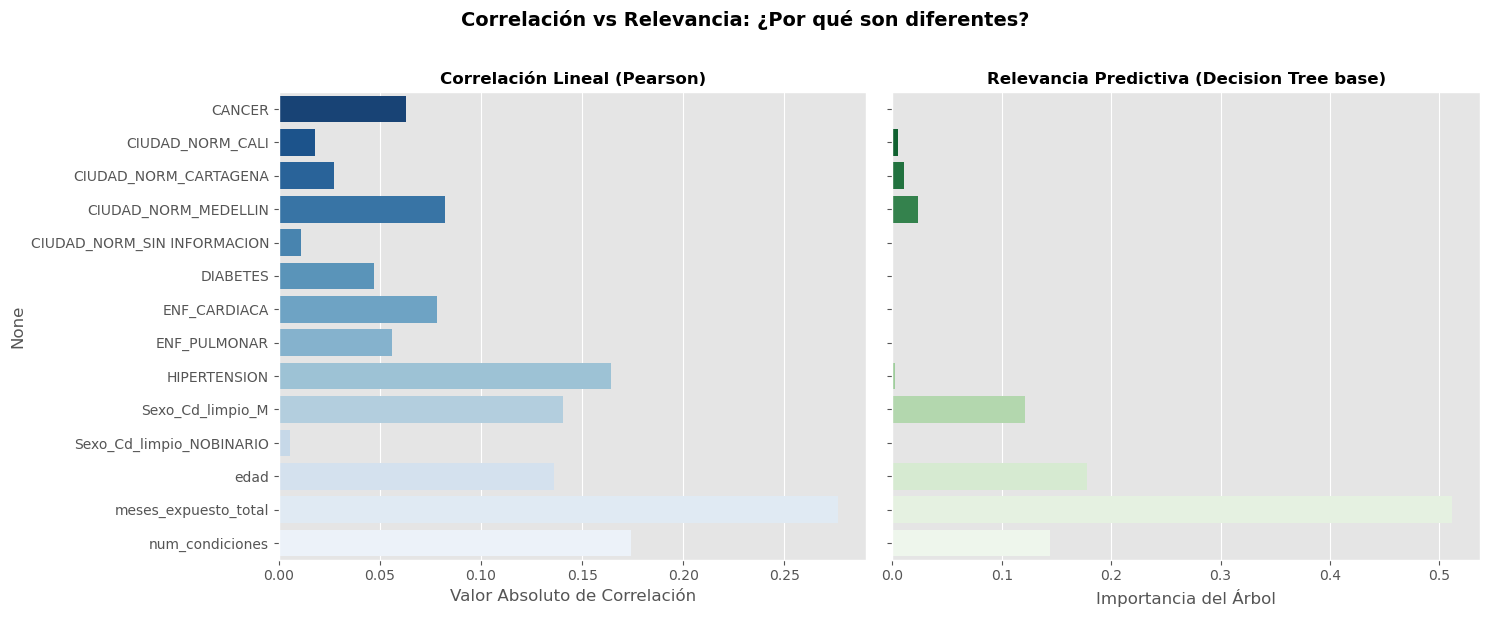

In [7]:
# Comparación final usando el modelo Decision Tree optimizado

modelo_para_importancia_dt = dt_optimizado if 'dt_optimizado' in globals() else dt_inicial
comparativa_dt = comparar_correlacion_vs_importancia(
    X,
    y_target,
    modelo_para_importancia_dt,
    nombre_modelo='Decision Tree optimizado' if 'dt_optimizado' in globals() else 'Decision Tree base'
)

# RESUMEN: Comparación entre Random Forest y Decision Tree

En esta sección compararemos el desempeño de ambos modelos optimizados para decidir cuál usar para la selección final de variables.

In [ ]:
print("=" * 80)
print("COMPARACIÓN DE DESEMPEÑO: Random Forest vs Decision Tree")
print("=" * 80)
print()

# Usar modelos optimizados si existen, si no usar los base
rf_model = grid_search.best_estimator_ if 'grid_search' in globals() and hasattr(grid_search, 'best_estimator_') else rf_inicial
dt_model = grid_search_dt.best_estimator_ if 'grid_search_dt' in globals() and hasattr(grid_search_dt, 'best_estimator_') else dt_inicial

rf_score = rf_model.score(X_val, y_val)
dt_score = dt_model.score(X_val, y_val)

print(f"Random Forest (Score R² en validación): {rf_score:.6f}")
print(f"Decision Tree  (Score R² en validación): {dt_score:.6f}")
print()

COMPARACIÓN DE DESEMPEÑO: Random Forest vs Decision Tree

Random Forest (Score R² en validación): 0.125813
Decision Tree  (Score R² en validación): 0.158426

